# ============================================
#  Notebook 02 — Missing Data Analysis
#  Memorial Sloan Kettering | Goel Lab
# ============================================

# Notebook 2: Missing Data Analysis at Observation Level

**Purpose:** Analyze missingness in the validation dataset at the observation level, grouped by feature and stratified by radiologic vs pathologic domains.

**Outputs:**
- Missingness summary table (per-feature)
- Radiologic Features Average Missing table
- Pathologic Features Average Missing table
- Heatmap of missingness by feature x observation
- Bar charts of missingness rates

**Template:** Adapted from `analyze missing_descriptive analysis_descriptive plots_tables.py`

In [1]:
import os
import sys
from pathlib import Path
from dotenv import load_dotenv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', lambda x: '%.3f' % x)
sns.set_style('whitegrid')

load_dotenv()

# ── Paths ─────────────────────────────────────────────────────────────────────
PROJECT_ROOT     = Path(os.getenv("PROJECT_ROOT",
    r"C:\Users\jamesr4\OneDrive - Memorial Sloan Kettering Cancer Center\Documents\GitHub\llm_summarization_br_ca"))
DATA_PRIVATE_DIR = Path(os.getenv("DATA_PRIVATE_DIR", r"C:\Users\jamesr4\loc\data_private"))

# Use deidentified Excel if available, otherwise fall back to raw
DEID_PATH = DATA_PRIVATE_DIR / "deidentified" / "validation_datasheet_deidentified.xlsx"
RAW_PATH  = DATA_PRIVATE_DIR / "raw" / "merged_llm_summary_validation_datasheet.xlsx"
DATA_PATH = DEID_PATH if DEID_PATH.exists() else RAW_PATH

OUTPUT_DIR = PROJECT_ROOT / "reports"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

data = pd.read_excel(DATA_PATH)
print(f"Using: {DATA_PATH.name}")
print(f"Dataset shape: {data.shape[0]} rows x {data.shape[1]} columns")

Using: validation_datasheet_deidentified.xlsx
Dataset shape: 200 rows x 49 columns


## 2.1 Element & Domain Definitions

In [2]:
ELEMENTS = {
    "Lesion Size": {"source": "lesion_size_status_source", "human": "lesion_size_status_human", "ai": "lesion_size_status_ai"},
    "Lesion Laterality": {"source": "laterality_status_source", "human": "laterality_status_human", "ai": "laterality_status_ai"},
    "Lesion Location": {"source": "lesion_location_status_source", "human": "lesion_location_status_human", "ai": "lesion_location_status_ai"},
    "Calcifications / Asymmetry": {"source": "calcifications_asymmetry_status_source", "human": "calcifications_asymmetry_status_human", "ai": "calcifications_asymmetry_status_ai"},
    "Additional Enhancement (MRI)": {"source": "additional_enhancement_mri_status_source", "human": "additional_enhancement_mri_status_human", "ai": "additional_enhancement_mri_status_ai"},
    "Extent": {"source": "extent_status_source", "human": "extent_status_human", "ai": "extent_status_ai"},
    "Accurate Clip Placement": {"source": "accurate_clip_placement_status_source", "human": "accurate_clip_placement_status_human", "ai": "accurate_clip_placement_status_ai"},
    "Workup Recommendation": {"source": "workup_recommendation_status_source", "human": "workup_recommendation_status_human", "ai": "workup_recommendation_status_ai"},
    "Lymph Node": {"source": "Lymph node_status_source", "human": "Lymph node_status_human", "ai": "Lymph node_status_ai"},
    "Chronology Preserved": {"source": "chronology_preserved_status_source", "human": "chronology_preserved_status_human", "ai": "chronology_preserved_status_ai"},
    "Biopsy Method": {"source": "biopsy_method_status_source", "human": "biopsy_method_status_human", "ai": "biopsy_method_status_ai"},
    "Invasive Component Size (Pathology)": {"source": "invasive_component_size_pathology_status_source", "human": "invasive_component_size_pathology_status_human", "ai": "invasive_component_size_pathology_status_ai"},
    "Histologic Diagnosis": {"source": "histologic_diagnosis_status_source", "human": "histologic_diagnosis_status_human", "ai": "histologic_diagnosis_status_ai"},
    "Receptor Status": {"source": "receptor_status_source", "human": "receptor_status_human", "ai": "receptor_status_ai"},
}

DOMAINS = {
    "Radiology": ["Lesion Size", "Lesion Laterality", "Lesion Location",
                  "Calcifications / Asymmetry", "Additional Enhancement (MRI)",
                  "Extent", "Accurate Clip Placement", "Workup Recommendation",
                  "Lymph Node", "Chronology Preserved", "Biopsy Method"],
    "Pathology": ["Biopsy Method", "Invasive Component Size (Pathology)",
                  "Histologic Diagnosis", "Receptor Status"],
}

# Normalize N/A strings
string_data = ["NA", "na", "n/a", "N/A", "NA ", " na", " n/a", " N/A"]
data = data.replace(string_data, "N/A")

## 2.2 Per-Feature Missingness Table

In [3]:
total_obs = len(data)
miss_rows = []

for element, cols in ELEMENTS.items():
    for role, col_name in cols.items():
        if col_name not in data.columns:
            n_miss = total_obs
        else:
            n_miss = int(data[col_name].isna().sum())
        pct = n_miss / total_obs * 100
        miss_rows.append({
            "Element": element,
            "Column Role": role,
            "Column Name": col_name,
            "n_missing": n_miss,
            "pct_missing": pct,
            "n_present": total_obs - n_miss,
        })

df_miss = pd.DataFrame(miss_rows).sort_values("pct_missing", ascending=False)
print(f"Missingness summary: {len(df_miss)} column entries")
df_miss

Missingness summary: 42 column entries


,Element,Column Role,Column Name,n_missing,pct_missing,n_present
14,Additional Enhancement (MRI),ai,additional_enhancement_mri_status_ai,108,54.000,92
13,Additional Enhancement (MRI),human,additional_enhancement_mri_status_human,108,54.000,92
17,Extent,ai,extent_status_ai,76,38.000,124
16,Extent,human,extent_status_human,76,38.000,124
11,Calcifications / Asymmetry,ai,calcifications_asymmetry_status_ai,59,29.500,141
10,Calcifications / Asymmetry,human,calcifications_asymmetry_status_human,59,29.500,141
23,Workup Recommendation,ai,workup_recommendation_status_ai,38,19.000,162
22,Workup Recommendation,human,workup_recommendation_status_human,38,19.000,162
35,Invasive Component Size (Pathology),ai,invasive_component_size_pathology_status_ai,36,18.000,164
34,Invasive Component Size (Pathology),human,invasive_component_size_pathology_status_human,36,18.000,164


## 2.3 Average Missing per Observation Grouped by Feature

In [4]:
# For each observation (row), count how many features are missing across source/human/ai
obs_miss = []
for idx, row in data.iterrows():
    for element, cols in ELEMENTS.items():
        for role in ["source", "human", "ai"]:
            col = cols[role]
            is_missing = 1 if (col not in data.columns or pd.isna(row.get(col))) else 0
            obs_miss.append({"obs_idx": idx, "Element": element, "role": role, "is_missing": is_missing})

df_obs_miss = pd.DataFrame(obs_miss)

# Average total missing per observation grouped by feature
avg_miss_by_feature = (
    df_obs_miss.groupby("Element")["is_missing"]
    .agg(["sum", "mean", "count"])
    .rename(columns={"sum": "total_missing", "mean": "avg_missing_rate", "count": "n_cells"})
    .sort_values("avg_missing_rate", ascending=False)
)
avg_miss_by_feature["avg_missing_rate_pct"] = avg_miss_by_feature["avg_missing_rate"] * 100
print("Average missing rate per feature (across source/human/ai x all observations):")
avg_miss_by_feature

Average missing rate per feature (across source/human/ai x all observations):


,total_missing,avg_missing_rate,n_cells,avg_missing_rate_pct
Element,,,,
Additional Enhancement (MRI),216,0.360,600,36.000
Extent,152,0.253,600,25.333
Calcifications / Asymmetry,118,0.197,600,19.667
Workup Recommendation,76,0.127,600,12.667
Invasive Component Size (Pathology),72,0.120,600,12.000
Lymph Node,44,0.073,600,7.333
Accurate Clip Placement,34,0.057,600,5.667
Receptor Status,26,0.043,600,4.333
Lesion Size,4,0.007,600,0.667


## 2.4 Radiologic Features Average Missing

In [5]:
rad_elements = DOMAINS["Radiology"]
df_rad_miss = avg_miss_by_feature.loc[avg_miss_by_feature.index.isin(rad_elements)].copy()
df_rad_miss = df_rad_miss.sort_values("avg_missing_rate", ascending=False)

print("Radiologic Features - Average Missing Rate")
print("=" * 50)
for elem, row in df_rad_miss.iterrows():
    print(f"  {elem:40s}  {row['avg_missing_rate_pct']:6.2f}%  (n_missing={int(row['total_missing'])})")
print(f"\n  {'DOMAIN AVERAGE':40s}  {df_rad_miss['avg_missing_rate_pct'].mean():6.2f}%")

df_rad_miss

Radiologic Features - Average Missing Rate
  Additional Enhancement (MRI)               36.00%  (n_missing=216)
  Extent                                     25.33%  (n_missing=152)
  Calcifications / Asymmetry                 19.67%  (n_missing=118)
  Workup Recommendation                      12.67%  (n_missing=76)
  Lymph Node                                  7.33%  (n_missing=44)
  Accurate Clip Placement                     5.67%  (n_missing=34)
  Lesion Size                                 0.67%  (n_missing=4)
  Biopsy Method                               0.33%  (n_missing=2)
  Chronology Preserved                        0.33%  (n_missing=2)
  Lesion Location                             0.33%  (n_missing=2)
  Lesion Laterality                           0.00%  (n_missing=0)

  DOMAIN AVERAGE                              9.85%


,total_missing,avg_missing_rate,n_cells,avg_missing_rate_pct
Element,,,,
Additional Enhancement (MRI),216,0.360,600,36.000
Extent,152,0.253,600,25.333
Calcifications / Asymmetry,118,0.197,600,19.667
Workup Recommendation,76,0.127,600,12.667
Lymph Node,44,0.073,600,7.333
Accurate Clip Placement,34,0.057,600,5.667
Lesion Size,4,0.007,600,0.667
Biopsy Method,2,0.003,600,0.333
Chronology Preserved,2,0.003,600,0.333


## 2.5 Pathologic Features Average Missing

In [6]:
path_elements = DOMAINS["Pathology"]
df_path_miss = avg_miss_by_feature.loc[avg_miss_by_feature.index.isin(path_elements)].copy()
df_path_miss = df_path_miss.sort_values("avg_missing_rate", ascending=False)

print("Pathologic Features - Average Missing Rate")
print("=" * 50)
for elem, row in df_path_miss.iterrows():
    print(f"  {elem:40s}  {row['avg_missing_rate_pct']:6.2f}%  (n_missing={int(row['total_missing'])})")
print(f"\n  {'DOMAIN AVERAGE':40s}  {df_path_miss['avg_missing_rate_pct'].mean():6.2f}%")

df_path_miss

Pathologic Features - Average Missing Rate
  Invasive Component Size (Pathology)        12.00%  (n_missing=72)
  Receptor Status                             4.33%  (n_missing=26)
  Biopsy Method                               0.33%  (n_missing=2)
  Histologic Diagnosis                        0.00%  (n_missing=0)

  DOMAIN AVERAGE                              4.17%


,total_missing,avg_missing_rate,n_cells,avg_missing_rate_pct
Element,,,,
Invasive Component Size (Pathology),72,0.120,600,12.000
Receptor Status,26,0.043,600,4.333
Biopsy Method,2,0.003,600,0.333
Histologic Diagnosis,0,0.000,600,0.000


## 2.6 Missingness Heatmap by Feature x Annotator

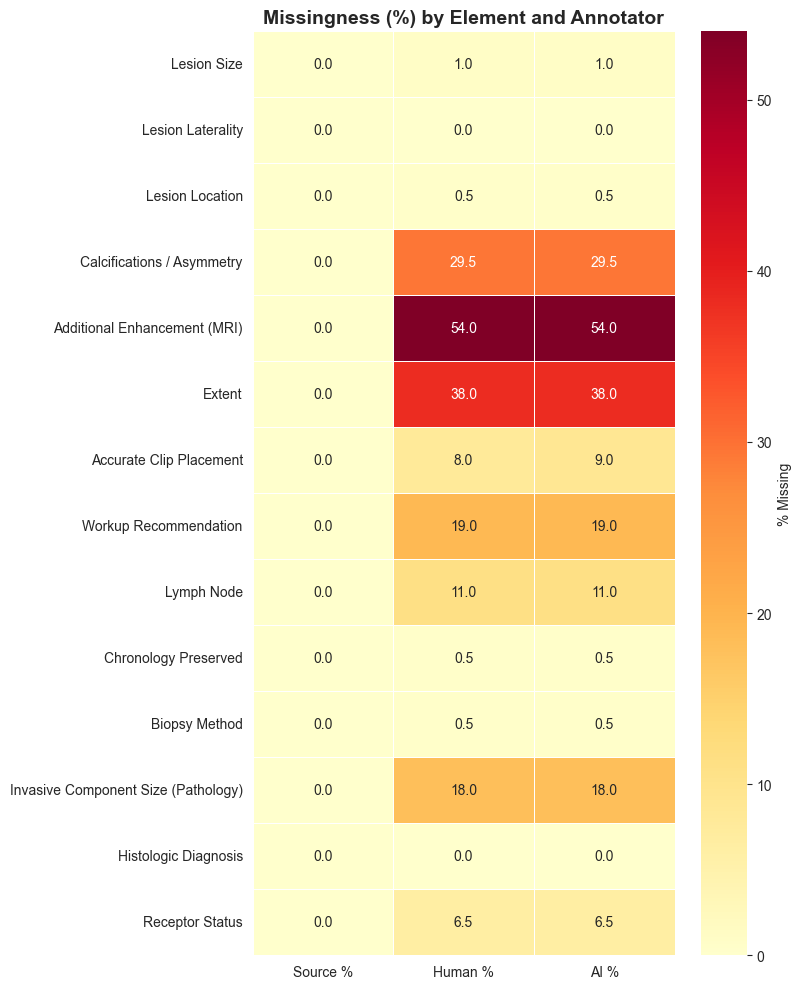

In [7]:
# Build a matrix: rows=elements, columns=[source_missing%, human_missing%, ai_missing%]
heat_rows = []
for element, cols in ELEMENTS.items():
    row = {"Element": element}
    for role in ["source", "human", "ai"]:
        col = cols[role]
        if col in data.columns:
            row[f"{role}_pct_missing"] = data[col].isna().mean() * 100
        else:
            row[f"{role}_pct_missing"] = 100.0
    heat_rows.append(row)

df_heat = pd.DataFrame(heat_rows).set_index("Element")
df_heat.columns = ["Source %", "Human %", "AI %"]

fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(df_heat, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5,
            cbar_kws={"label": "% Missing"}, ax=ax)
ax.set_title("Missingness (%) by Element and Annotator", fontsize=14, fontweight="bold")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "missingness_heatmap_by_feature_annotator.png", dpi=300)
plt.show()

## 2.7 Bar Chart: Missing Rate by Feature (Human vs AI)

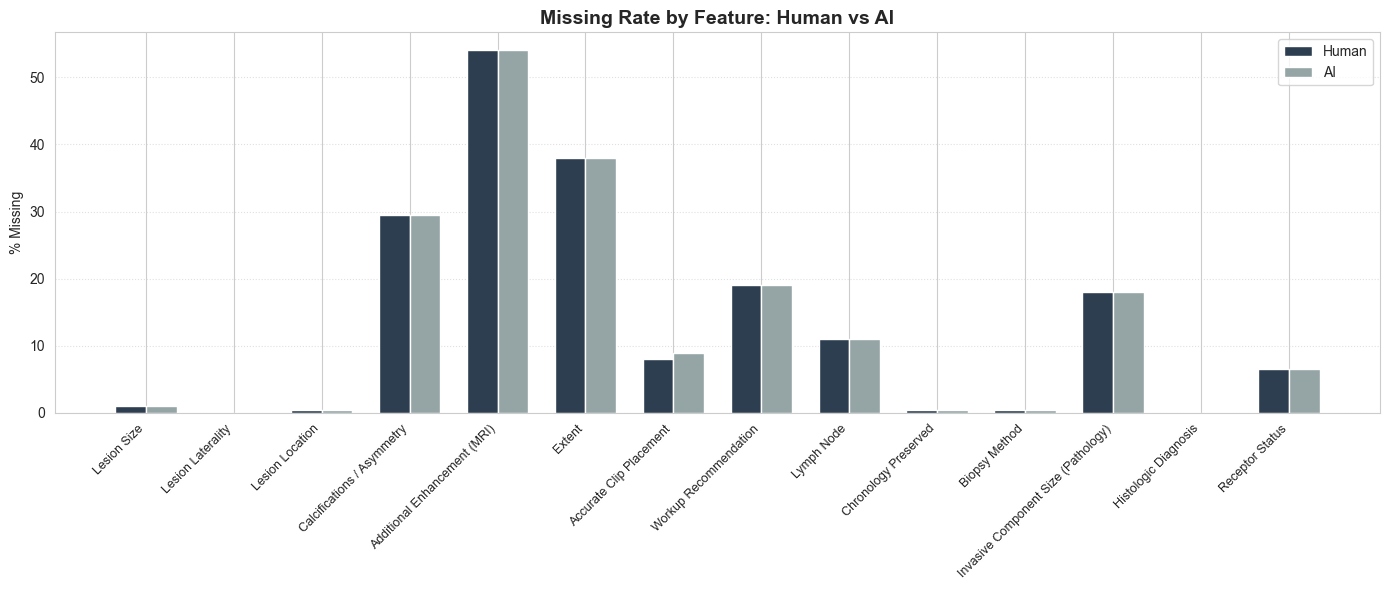

In [8]:
# Focus on human and AI missingness per element
bar_rows = []
for element, cols in ELEMENTS.items():
    for role in ["human", "ai"]:
        col = cols[role]
        pct = data[col].isna().mean() * 100 if col in data.columns else 100.0
        bar_rows.append({"Element": element, "Annotator": role.title(), "pct_missing": pct})

df_bar = pd.DataFrame(bar_rows)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(ELEMENTS))
width = 0.35
human_vals = df_bar[df_bar["Annotator"] == "Human"]["pct_missing"].values
ai_vals = df_bar[df_bar["Annotator"] == "Ai"]["pct_missing"].values

ax.bar(x - width/2, human_vals, width, label="Human", color="#2c3e50")
ax.bar(x + width/2, ai_vals, width, label="AI", color="#95a5a6")
ax.set_xticks(x)
ax.set_xticklabels(list(ELEMENTS.keys()), rotation=45, ha="right", fontsize=9)
ax.set_ylabel("% Missing")
ax.set_title("Missing Rate by Feature: Human vs AI", fontsize=14, fontweight="bold")
ax.legend()
ax.grid(axis="y", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "missingness_bar_human_vs_ai.png", dpi=300)
plt.show()

## 2.8 Domain-Level Missingness Summary

In [9]:
domain_summary = []
for domain, elements in DOMAINS.items():
    domain_miss = avg_miss_by_feature.loc[avg_miss_by_feature.index.isin(elements)]
    domain_summary.append({
        "Domain": domain,
        "n_elements": len(elements),
        "avg_missing_rate_pct": domain_miss["avg_missing_rate_pct"].mean(),
        "max_missing_rate_pct": domain_miss["avg_missing_rate_pct"].max(),
        "min_missing_rate_pct": domain_miss["avg_missing_rate_pct"].min(),
        "total_missing_cells": int(domain_miss["total_missing"].sum()),
    })

df_domain_miss = pd.DataFrame(domain_summary)
print("Domain-Level Missingness Summary")
df_domain_miss

Domain-Level Missingness Summary


,Domain,n_elements,avg_missing_rate_pct,max_missing_rate_pct,min_missing_rate_pct,total_missing_cells
0,Radiology,11,9.848,36.000,0.000,650
1,Pathology,4,4.167,12.000,0.000,100


## 2.9 Per-Observation Missing Count Distribution

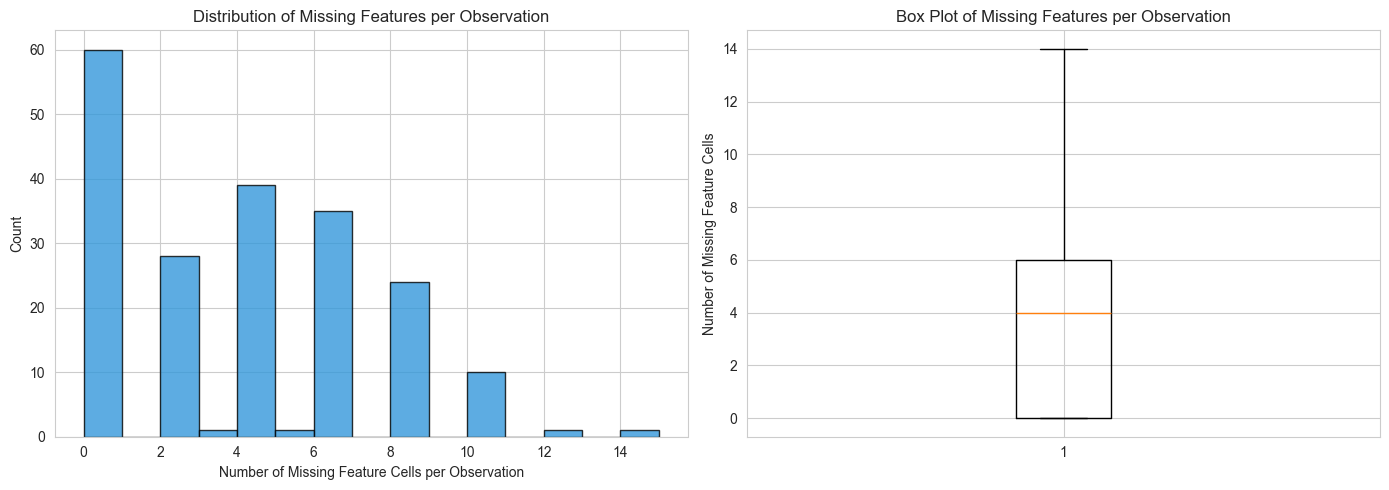

Mean missing per observation: 3.74
Median: 4
Max: 14


In [10]:
# For each row, count total missing across all element columns (source + human + ai)
all_cols = []
for cols in ELEMENTS.values():
    for role in ["source", "human", "ai"]:
        if cols[role] in data.columns:
            all_cols.append(cols[role])

data["total_missing_features"] = data[all_cols].isna().sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(data["total_missing_features"], bins=range(0, int(data["total_missing_features"].max()) + 2),
             edgecolor="black", color="#3498db", alpha=0.8)
axes[0].set_xlabel("Number of Missing Feature Cells per Observation")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Missing Features per Observation")

# Box plot
axes[1].boxplot(data["total_missing_features"].dropna(), vert=True)
axes[1].set_ylabel("Number of Missing Feature Cells")
axes[1].set_title("Box Plot of Missing Features per Observation")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "missingness_per_observation_distribution.png", dpi=300)
plt.show()

print(f"Mean missing per observation: {data['total_missing_features'].mean():.2f}")
print(f"Median: {data['total_missing_features'].median():.0f}")
print(f"Max: {data['total_missing_features'].max():.0f}")

## 2.10 Save All Tables

In [11]:
df_miss.to_csv(OUTPUT_DIR / "missingness_per_feature_column.csv", index=False)
avg_miss_by_feature.to_csv(OUTPUT_DIR / "missingness_avg_by_feature.csv")
df_rad_miss.to_csv(OUTPUT_DIR / "missingness_radiologic_features.csv")
df_path_miss.to_csv(OUTPUT_DIR / "missingness_pathologic_features.csv")
df_domain_miss.to_csv(OUTPUT_DIR / "missingness_domain_summary.csv", index=False)

print("Saved:")
print(f"  {OUTPUT_DIR / 'missingness_per_feature_column.csv'}")
print(f"  {OUTPUT_DIR / 'missingness_avg_by_feature.csv'}")
print(f"  {OUTPUT_DIR / 'missingness_radiologic_features.csv'}")
print(f"  {OUTPUT_DIR / 'missingness_pathologic_features.csv'}")
print(f"  {OUTPUT_DIR / 'missingness_domain_summary.csv'}")

Saved:
  C:\Users\jamesr4\OneDrive - Memorial Sloan Kettering Cancer Center\Documents\GitHub\llm_summarization_br_ca\reports\missingness_per_feature_column.csv
  C:\Users\jamesr4\OneDrive - Memorial Sloan Kettering Cancer Center\Documents\GitHub\llm_summarization_br_ca\reports\missingness_avg_by_feature.csv
  C:\Users\jamesr4\OneDrive - Memorial Sloan Kettering Cancer Center\Documents\GitHub\llm_summarization_br_ca\reports\missingness_radiologic_features.csv
  C:\Users\jamesr4\OneDrive - Memorial Sloan Kettering Cancer Center\Documents\GitHub\llm_summarization_br_ca\reports\missingness_pathologic_features.csv
  C:\Users\jamesr4\OneDrive - Memorial Sloan Kettering Cancer Center\Documents\GitHub\llm_summarization_br_ca\reports\missingness_domain_summary.csv
